In [1]:
import kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
!

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!ls gdrive/MyDrive

ls: cannot access 'gdrive/MyDrive': No such file or directory


In [6]:
!unzip gdrive/MyDrive/chest-xray-pneumonia.zip -d gdrive/MyDrive/chest-xray-pneumonia/

unzip:  cannot find or open gdrive/MyDrive/chest-xray-pneumonia.zip, gdrive/MyDrive/chest-xray-pneumonia.zip.zip or gdrive/MyDrive/chest-xray-pneumonia.zip.ZIP.


In [7]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Streaming output truncated to the last 5000 lines.
                person952_bacteria_2877.jpeg
                person1315_virus_2270.jpeg
                person1392_bacteria_3538.jpeg
                person475_bacteria_2025.jpeg
                person1288_bacteria_3251.jpeg
                person1005_virus_1688.jpeg
                person442_virus_900.jpeg
                person755_bacteria_2659.jpeg
                person655_bacteria_2547.jpeg
                person126_virus_255.jpeg
                person16_bacteria_53.jpeg
                person364_virus_743.jpeg
                person382_bacteria_1745.jpeg
                person898_bacteria_2823.jpeg
                person1145_virus_1906.jpeg
                person1004_bacteria_2935.jpeg
                person1088_virus_1800.jpeg
                person501_bacteria_2112.jpeg
                person1718_bacteria_4540.jpeg
                person775_bacteria_2679.jpeg
                person550_bacteria_2309.jpeg
                person7

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
# setting the training data

In [9]:
# setting the training data directory
DataDir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
!ls {DataDir}

NORMAL	PNEUMONIA


In [10]:
# intiallizing the category
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [11]:
#DataDir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
!ls {DataDir}

NORMAL	PNEUMONIA


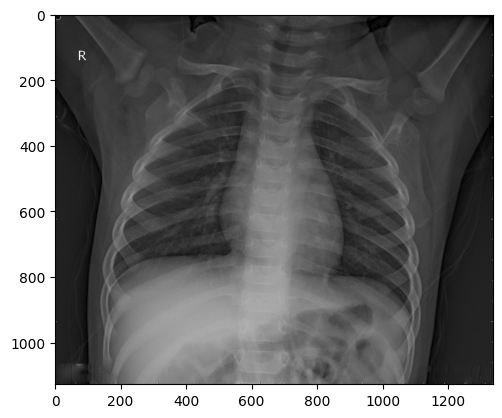

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# converting the images into grayscale
for i in CATEGORIES:
  path=os.path.join(DataDir,i)
  for img in os.listdir(path):
    img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
    plt.imshow(img_array, cmap='gray')
    plt.show()
    break
  break

In [13]:
# Initializing the size of the image so that every image should be in same dimension


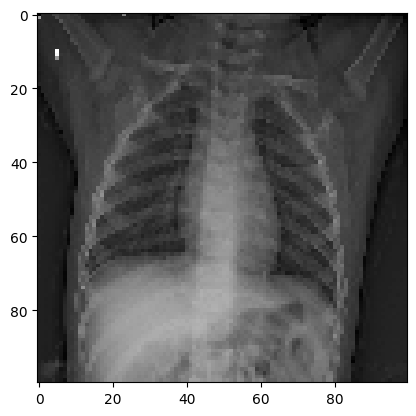

In [14]:
img_size=100
# image after resize and gray scale
new_array = cv2.resize(img_array, (img_size, img_size))
plt.imshow(new_array, cmap='gray')
plt.show()

In [15]:
training_data = []

In [16]:
# Defining the function for training data according to the categories converting the images into gray scale with
# converting it into numpy arrays
def create_training_data(data_directory, training_data=[]):
  for category in CATEGORIES:
    path = os.path.join(data_directory, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
          new_array =cv2.resize(img_array,(img_size,img_size))
          training_data.append([new_array, class_num])
        except Exception as e:
          pass

In [17]:
training_data = []
DataDir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
create_training_data(DataDir, training_data)
print(f"Length of training_data: {len(training_data)}")

Length of training_data: 5216


In [18]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
  print(sample)

[array([[199, 188, 177, ...,  32,  25,  13],
       [200, 193, 179, ...,  35,  30,  21],
       [189, 191, 173, ...,  41,  36,  24],
       ...,
       [  7,   6,   6, ...,   3,   3,   3],
       [  6,   6,   5, ...,   3,   3,   3],
       [  6,   6,   5, ...,   3,   3,   3]], dtype=uint8), 1]
[array([[51, 50, 50, ..., 62, 60, 52],
       [49, 49, 50, ..., 61, 61, 52],
       [49, 52, 50, ..., 60, 62, 53],
       ...,
       [48, 50, 59, ...,  0,  7,  9],
       [46, 51, 65, ...,  0,  3, 10],
       [45, 49, 64, ...,  0,  7, 10]], dtype=uint8), 1]
[array([[70, 74, 72, ..., 56, 51, 44],
       [61, 63, 67, ..., 53, 42, 40],
       [49, 53, 63, ..., 55, 42, 34],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[14,  9, 25, ...,  9, 10, 10],
       [36, 45, 45, ..., 27,  3,  7],
       [41, 46, 44, ..., 39, 31,  0],
       ...,
       [25, 27, 25, ..., 23, 24, 19],
       [27, 27, 26, ..

In [19]:
X =[]
y = []


In [20]:
# Spliting the features  and labels
for features, label in training_data:
  X.append(features)
  y.append(label)


In [21]:
print(X[0].reshape(-1, img_size, img_size, 1))

[[[[199]
   [188]
   [177]
   ...
   [ 32]
   [ 25]
   [ 13]]

  [[200]
   [193]
   [179]
   ...
   [ 35]
   [ 30]
   [ 21]]

  [[189]
   [191]
   [173]
   ...
   [ 41]
   [ 36]
   [ 24]]

  ...

  [[  7]
   [  6]
   [  6]
   ...
   [  3]
   [  3]
   [  3]]

  [[  6]
   [  6]
   [  5]
   ...
   [  3]
   [  3]
   [  3]]

  [[  6]
   [  6]
   [  5]
   ...
   [  3]
   [  3]
   [  3]]]]


In [22]:
y = np.array(y)

In [23]:
# reshapping the features for making it compatible with tensorflow
X = np.array(X).reshape(-1, img_size, img_size, 1)

In [24]:
# as we do for training data similiarly doing with validation data
#validation_data = []
#DataDir_val = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
#create_data(DataDir_val, validation_data)
#print(f"Length of validation_data: {len(validation_data)}")

In [25]:
def create_training_data(data_directory, target_list):
  for i in CATEGORIES:
    path = os.path.join(data_directory, i)
    class_num = CATEGORIES.index(i)
    for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
          new_array =cv2.resize(img_array,(img_size,img_size))
          target_list.append([new_array, class_num])
        except Exception as e:
          pass

In [26]:
validation_data = []
DataDir_val = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
create_training_data(DataDir_val, validation_data)
print(f"Length of validation_data: {len(validation_data)}")

Length of validation_data: 16


In [27]:
print(len(validation_data))

16


In [28]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[  8,  96,  46, ...,  19,  19,  14],
       [  1, 100,  80, ...,  26,  23,  16],
       [ 77,  73, 112, ...,  24,  20,  16],
       ...,
       [  0,   3,   7, ...,   0,   0,   0],
       [  0,   0,   6, ...,   0,   0,   0],
       [  1,   0,   0, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       ...,
       [  3,   3,   3, ..., 222,  51,   7],
       [  3,   3,   3, ..., 190,  58,  10],
       [  3,   4,   4, ...,  48,  14,   9]], dtype=uint8), 1]
[array([[64, 63, 64, ..., 97, 93, 93],
       [51, 52, 50, ..., 90, 92, 90],
       [39, 41, 44, ..., 96, 86, 86],
       ...,
       [16, 51, 78, ...,  2,  2,  6],
       [28, 56, 80, ...,  2,  1,  8],
       [35, 61, 87, ...,  2, 10,  7]], dtype=uint8), 1]
[array([[  0,  20,  15, ...,  10,  14,  15],
       [239,  19,  15, ...,  12,  13,  14],
       [ 21,  18,  15, ...,  11,  14,  15],
       ...,
      

In [29]:
X_val =[]
y_val = []

In [30]:
for features, label in validation_data:
  X_val.append(features)
  y_val.append(label)

In [31]:
y_val = np.array(y_val)
X_val = np.array(X_val).reshape(-1, img_size, img_size, 1)

In [32]:
# Import the library for trainin the mode and adding the neural nework layers

In [33]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
import pickle

In [34]:
from keras.layers import Conv2D, MaxPooling2D

In [35]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white
# In order tol scale it down to a scale down we need to divide it 0 to 1 X=X/255.0
X=X/255.0
x_val=X_val/255.0

In [36]:
X.shape

(5216, 100, 100, 1)

In [37]:
x_val.shape

(16, 100, 100, 1)

In [38]:
# Intializing the neural network for training the model
model = Sequential()

model.add(Conv2D(64,(3,3),input_shape = X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [ ]:
# Fitting the model with 10 epochs and using the validation data we havee created
model.fit(X,y, batch_size=4, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
1252/1304 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8216 - loss: 0.4101

In [ ]:
# saving the model
model.save(r'model_10.h5')

In [ ]:
# importing the library for testing the model

import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from keras.models import load_model

In [ ]:
import matplotlib.image as mpimg

In [ ]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [ ]:
# function for preparing the image for predicting
def prepare(image):
  img_size = 100
  #img_array=cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  img =tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array=tf.keras.preprocessing.image.img_to_array(img)
  return new_array.reshape(-1, img_size, img_size, 1)

In [ ]:
model=tf.keras.models.load_model(r"model_10.h5")

In [ ]:
image=r'/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg'

In [ ]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

In [ ]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()